# Laboratorium 9 - Sieci Rekurencyjne

Na tym laboratorium zapoznamy się z sieciami rekurencyjnymi - jedną z architektur dedykowanych danym sekwencyjnym. Dla danych sekwencyjnych, jednym z naturalnych podejść do modelowania jest założenie, że przetwarzając n-ty krok, możemy udostępnić modelowi pewną reprezentację historii/pamięci/stanu która w kompaktowy sposób przechowuje informację o "wszystkim co działo się wcześniej". W ten sposób zadania upraszcza sobie często np. modelowanie procesami stochastycznymi (założenie własności Markowa w modelu). W kontekście sieci neuronowych, odpowiednikiem takiego podejścia jest właśnie warstwa rekurencyjna: taka, która w n-tym kroku przetwarza n-te wejście i reprezentacje ukrytą z kroku n-1 (historię/stan/pamięć).

Oczywiście z góry warstwo wspomnieć o fakcie, że architektury rekurencyjne obecnie nie są pierwszym wyborem, w pracach state=of-the-art dominuje mechanizm uwagi. Transformery to obecnie podstawa wszystkiego, co kojarzone z sztuczną inteligencją - w szczególności wszelkiej maści "czatów" opartych o LLM (Large Language Models). Ale ich historia to w pierwszej kolejności dodanie mechanizmu uwagi do sieci rekurencyjnych, a dopiero potem spostrzeżenie, że po dodaniu tego mechanizmu, rekurencja nie jest już w zasadzie konieczna (bardzo znana publikacja *Attention Is All You Need*).

 Na tych laboratoriach przyjrzyjmy się warstwom LSTM - najpopularniejszej wersji architektury czysto rekurencyjnej.

# Zbiory danych

Przeprowadzimy test na dwóch zbiorach danych: klasyczny zbiór do analizy sentymentu tekstów (recenzje IMDB), oraz zbiór audio - rozpoznawanie owadów po wydawanych rzez nich odgłosach.

In [1]:
from tensorflow.keras.datasets import imdb

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    path='imdb.npz',
    num_words=None,
    skip_top=0,
    maxlen=None,
    seed=113,
    start_char=1,
    oov_char=2,
    index_from=3
)

I0000 00:00:1779071100.627659     269 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779071100.950367     269 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779071103.294864     269 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
print(x_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 31050, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [3]:
!pip install aeon


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [4]:
from aeon.datasets import load_classification
X, y = load_classification("InsectWingbeat", extract_path="insect_data")


/tmp/ipykernel_269/2878833984.py:2: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X, y = load_classification("InsectWingbeat", extract_path="insect_data")


In [5]:
print(X[0])

[[-5.2600e-04 -6.8000e-04 -1.0782e-02 ...  1.9104e-02 -1.8969e-02
  -9.8000e-04]
 [ 4.2600e-04  2.9300e-04  1.3112e-02 ... -9.1000e-05 -3.2437e-02
  -2.5000e-05]
 [-4.9000e-04 -4.4300e-04 -1.2667e-02 ... -9.7161e-01 -2.8844e-02
   9.1500e-04]
 ...
 [ 6.5200e-04  5.2600e-04 -2.0744e-02 ...  2.0344e-02 -4.3800e-03
   7.9350e-03]
 [-8.1800e-04  2.4800e-04  2.6454e-02 ...  2.0116e-02 -3.5250e-03
  -2.4500e-04]
 [-8.1800e-04  2.4800e-04  2.6454e-02 ...  2.0116e-02 -3.5250e-03
  -2.4500e-04]]


# Wczytywanie danych sekwencyjnych

Dla danych sekwencyjnych, przy przetwarzaniu w batchu pojawia się nowa komplikacja: batch musi być możliwy do "spakowania" w tensorze `batch_size x vector_dimension x sequence_length `, podczas gdy sekwencje w zbiorze uczącym nie muszą być jednakowego rozmiaru. Rozwiązaniem jest padding: dopełnianie tensorów zerami do stałej długości.

W problemach klasyfikacyjnych to powoduje jednak nowy problem: chcemy uzyskać reprezentację do klasyfikacji na końcu właściwej sekwencji, nie po przetworzeniu kilu (nastu/dziesięciu/set) dodatkowych wektorów zer. Implementacje warstw rekurencyjnych w torchu oferują nam rozwiązanie w postaci obiektów PackedSequence. Odpowiednimi funkcjami możemy "spakować" zarówno listę sekencji, jak i tensor już wypadowanych danych z podanymi osobno długościami sekwencji. Podanie takiej paczki na wejści warstwy rekurencyjnej gwarantuje, że warstwa zwróci nam swoją reprezentację na poziomie **ostatniego elementu właściwej sekwencji** (nie biorąc pod uwagę paddingu).

In [6]:
import torch

sequences = [[0,1,2,3],
             [0,1],
             [0]]

packed_sequences = torch.nn.utils.rnn.pack_sequence([torch.tensor(seq) for seq in sequences])
print(packed_sequences)

padded_sequences = torch.nn.utils.rnn.pad_sequence([torch.tensor(seq) for seq in sequences])
print(padded_sequences)

packed_padded_sequences = torch.nn.utils.rnn.pack_padded_sequence(padded_sequences, [len(s) for s in sequences])
print(packed_padded_sequences)

PackedSequence(data=tensor([0, 0, 0, 1, 1, 2, 3]), batch_sizes=tensor([3, 2, 1, 1]), sorted_indices=None, unsorted_indices=None)
tensor([[0, 0, 0],
        [1, 1, 0],
        [2, 0, 0],
        [3, 0, 0]])
PackedSequence(data=tensor([0, 0, 0, 1, 1, 2, 3]), batch_sizes=tensor([3, 2, 1, 1]), sorted_indices=None, unsorted_indices=None)


# Zadanie 1

Zaimplementuj obiekty Dataset i DataLoader dla naszych zbiorów danych w wariantach zwracających zarówno obiekt PackedSequences, jak i prosty tensor z  wypadowanym zerami batchem.

In [7]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader, Subset
from torch.nn.utils.rnn import pad_sequence, pack_sequence

class IMDBDataset(Dataset):
    def __init__(self, x, y):
        self.x = [torch.tensor(seq, dtype=torch.long) for seq in x]
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

class InsectDataset(Dataset):
    def __init__(self, X, y):
        # X: (n_samples, n_channels, n_timepoints) — aeon format
        # Zamieniamy na listę tensorów [n_timepoints, n_channels]
        self.x = [torch.tensor(X[i].T, dtype=torch.float32) for i in range(len(X))]

        classes = sorted(set(y))
        label_map = {c: i for i, c in enumerate(classes)}
        self.y = torch.tensor([label_map[yi] for yi in y], dtype=torch.long)
        self.classes = classes

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


In [ ]:
def collate_padded(batch):
    """
    Zwraca (padded_tensor, lengths, labels).
    padded_tensor ma kształt [max_len, batch_size, features].
    """
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in sequences])
    padded = pad_sequence(sequences, batch_first=False, padding_value=0)
    return padded, lengths, torch.stack(labels)

def collate_packed(batch):
    """
    Zwraca (PackedSequence, labels).
    enforce_sorted=False — DataLoader może losowo mieszać kolejność.
    """
    sequences, labels = zip(*batch)
    packed = pack_sequence(list(sequences), enforce_sorted=False)
    return packed, torch.stack(labels)


In [9]:
def get_imdb_dataloaders(x_train, y_train, x_test, y_test,
                         batch_size=32, variant='padded'):
    """variant: 'padded' | 'packed'"""
    train_ds = IMDBDataset(x_train, y_train)
    test_ds  = IMDBDataset(x_test,  y_test)

    collate_fn = collate_padded if variant == 'padded' else collate_packed

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  collate_fn=collate_fn)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size,
                              shuffle=False, collate_fn=collate_fn)
    return train_loader, test_loader


def get_insect_dataloaders(X, y, batch_size=32, variant='padded',
                           test_ratio=0.2, seed=42):
    """variant: 'padded' | 'packed'"""
    dataset = InsectDataset(X, y)
    n = len(dataset)

    rng = np.random.default_rng(seed)
    indices = rng.permutation(n).tolist()
    split = int(n * (1 - test_ratio))

    train_ds = Subset(dataset, indices[:split])
    test_ds  = Subset(dataset, indices[split:])

    collate_fn = collate_padded if variant == 'padded' else collate_packed

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  collate_fn=collate_fn)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size,
                              shuffle=False, collate_fn=collate_fn)
    return train_loader, test_loader


# Embedding

Warstwy embeddingu są elementem wykorzystywanym przy przetwarzaniu danych, gdzie elementem jest id w pewnym dyskretnym zbiorze obiektów. Przykładowo, dla danych językowych może być to zbiór możliwych słów. Warstwa przyporządkowuje każdemu id jego własny wektor, i zakładamy, że w trakcie uczenia wyuczy się podobieństwa między obiektami.

## Model LSTM

W teorii, warstwy LSTM potrafią zapamiętywać "długoterminowo" a więc to skąd wyciągamy dane nie powinno robić większego problemu. Sprawdźmy czy tak jest w rzeczywistości, implementując wersję prostego eksperymentu - implementując uczenie zarówno z wykorzystaniem obiektów PackedSequence, jak i zwyczajnych tensorów dopełnionych zerami.

Nasz model LSTM musi być przygotowany na wszystkie opisane wersje naszego eksperymentu: dane w postaci sekwencji już w przestrzeni cech i w postaci sekwencji Integerów z embeddingiem w obrębie sieci; wykorzystanie PacekdSequences lub nie.

(**UWAGA:** W przypadku wykorzystania Embeddingu i Packed Sequences jednocześnie, będzie trzeba rozpakować, embedować i spakować jeszcze raz. Obsługiwanie tych czterech wariantów w jednej klasie nie jest praktyczne, potraktuj je raczej jako ćwiczenie.)

In [10]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_packed_sequence, pack_padded_sequence

class LSTMNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes,
                 bidirectional=False, embed=False, packed=False):
        super(LSTMNet, self).__init__()
        self.embed    = embed
        self.packed   = packed
        self.bidirectional = bidirectional

        # Gdy embed=True: input_size = rozmiar słownika (vocab_size),
        # wymiar embeddingu ustawiamy na hidden_size
        if embed:
            self.embedding = nn.Embedding(input_size, hidden_size)
            lstm_input_size = hidden_size
        else:
            lstm_input_size = input_size

        self.lstm = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            bidirectional=bidirectional,
            batch_first=False,
        )

        fc_in = hidden_size * (2 if bidirectional else 1)
        self.fc = nn.Linear(fc_in, num_classes)

    def forward(self, x):
        if self.packed and self.embed:
            # 1) PackedSequence z integerami → rozpakuj, embeduj, spakuj ponownie
            padded, lengths = pad_packed_sequence(x, batch_first=False)
            embedded = self.embedding(padded)           # [T, B, embed_dim]
            x = pack_padded_sequence(embedded, lengths.cpu(),
                                     batch_first=False, enforce_sorted=False)
            _, (h_n, _) = self.lstm(x)

        elif self.packed:
            # 2) PackedSequence z cechami → bezpośrednio do LSTM
            _, (h_n, _) = self.lstm(x)

        elif self.embed:
            # 3) Padded tensor z integerami [T, B] → embedding → LSTM
            embedded = self.embedding(x)               # [T, B, embed_dim]
            _, (h_n, _) = self.lstm(embedded)

        else:
            # 4) Padded tensor z cechami [T, B, input_size] → LSTM
            _, (h_n, _) = self.lstm(x)

        # h_n: [num_layers * num_directions, B, hidden_size]
        if self.bidirectional:
            # ostatnia warstwa: forward = h_n[-2], backward = h_n[-1]
            last = torch.cat([h_n[-2], h_n[-1]], dim=-1)  # [B, hidden_size*2]
        else:
            last = h_n[-1]                                 # [B, hidden_size]

        return self.fc(last)


## Uczenie

Pętla ucząca dla modelu LSTM będzie analogiczna do znanych nam wcześniej

In [11]:
def validate_clf(model, loss_fn, dataloader, num_classes, device='cuda'):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    tps = torch.zeros(num_classes, device=device)
    fps = torch.zeros(num_classes, device=device)
    fns = torch.zeros(num_classes, device=device)

    with torch.no_grad():
        for batch in dataloader:
            x, y = batch[0], batch[-1]
            x = x.to(device)   # działa dla Tensor i PackedSequence
            y = y.to(device)
            out = model(x)
            total_loss += loss_fn(out, y).item()

            preds = torch.argmax(out, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

            for c in range(num_classes):
                tps[c] += ((preds == c) & (y == c)).sum()
                fps[c] += ((preds == c) & (y != c)).sum()
                fns[c] += ((preds != c) & (y == c)).sum()

    acc = correct / total
    precisions = tps / (tps + fps + 1e-8)
    recalls    = tps / (tps + fns + 1e-8)
    macro_f1   = (2 * precisions * recalls / (precisions + recalls + 1e-8)).mean().item()

    return total_loss / len(dataloader), acc, macro_f1


def fit_clf(model, optimiser, loss_fn, train_dl, val_dl,
            epochs, num_classes, device='cuda'):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct, train_total = 0, 0

        for batch in train_dl:
            x, y = batch[0], batch[-1]
            x = x.to(device)
            y = y.to(device)
            optimiser.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimiser.step()
            train_loss += loss.item()
            train_correct += (torch.argmax(out, dim=1) == y).sum().item()
            train_total += y.size(0)

        train_loss /= len(train_dl)
        train_acc = train_correct / train_total
        val_loss, val_acc, val_f1 = validate_clf(model, loss_fn, val_dl, num_classes, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    return history



## Zadanie 2

Przeprowadź uczenie modelu LSTM na zadanym zbiorze i porównaj następujące podejścia:

*   LSTM, dane z paddingiem do długości najdłuższej sekwencji w batchu
*   Jak wyżej, ale Bidirectional
*   LSTM (nie bidirectional) z wykorzystaniem obiektów PaddedSequences

In [20]:
import torch.optim as optim
import matplotlib.pyplot as plt
import time

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH  = 64
HIDDEN = 128
LAYERS = 2
EPOCHS = 5
LR     = 1e-3

def run_experiment(label, model_cfg, train_dl, test_dl, num_classes,epochs=EPOCHS):
    print(f"\n--- {label} ---")
    model = LSTMNet(**model_cfg).to(DEVICE)
    t0 = time.time()
    h = fit_clf(model, optim.Adam(model.parameters(), LR),
                nn.CrossEntropyLoss(), train_dl, test_dl, epochs, num_classes, DEVICE)
    elapsed = time.time() - t0
    print(f"Czas: {elapsed/60:.1f} min ({elapsed:.0f}s)")
    return h, model



def plot_results(results, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title)
    for name, h, ls in results:
        axes[0].plot(h['val_loss'], ls=ls, label=name)
        axes[1].plot(h['val_acc'],  ls=ls, label=name)
    axes[0].set_title('Val Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].set_title('Val Acc');  axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout()
    plt.show()

    print(f"\n{'Wariant':<25} {'Best Acc':>10} {'Best F1':>10}")
    print("-" * 47)
    for name, h, _ in results:
        print(f"{name:<25} {max(h['val_acc']):>10.4f} {max(h['val_f1']):>10.4f}")


In [13]:
# ── IMDB ──────────────────────────────────────────────────────────────────────
NUM_WORDS = 10000
VOCAB_SIZE = NUM_WORDS + 3  # +3 bo index_from=3

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    path='imdb.npz',
    num_words=NUM_WORDS,
    skip_top=0,
    maxlen=400,
    seed=113,
    start_char=1,
    oov_char=2,
    index_from=3
)

train_ds_imdb = IMDBDataset(x_train, y_train)
test_ds_imdb  = IMDBDataset(x_test,  y_test)

dl_pad  = DataLoader(train_ds_imdb, BATCH, shuffle=True,  collate_fn=collate_padded)
dl_pad_v = DataLoader(test_ds_imdb,  BATCH, shuffle=False, collate_fn=collate_padded)
dl_pack  = DataLoader(train_ds_imdb, BATCH, shuffle=True,  collate_fn=collate_packed)
dl_pack_v = DataLoader(test_ds_imdb,  BATCH, shuffle=False, collate_fn=collate_packed)

BASE_IMDB = dict(input_size=VOCAB_SIZE, hidden_size=HIDDEN,
                 num_layers=LAYERS, num_classes=2, embed=True)

h_imdb_pad, m1   = run_experiment("IMDB: LSTM + padded",   {**BASE_IMDB, 'bidirectional': False, 'packed': False}, dl_pad,   dl_pad_v,  2)
h_imdb_bi, m2    = run_experiment("IMDB: BiLSTM + padded", {**BASE_IMDB, 'bidirectional': True,  'packed': False}, dl_pad,   dl_pad_v,  2)
h_imdb_pack, m3  = run_experiment("IMDB: LSTM + packed",   {**BASE_IMDB, 'bidirectional': False, 'packed': True},  dl_pack,  dl_pack_v, 2)


--- IMDB: LSTM + padded ---
Epoch 1/5 | Train Loss: 0.6936 | Train Acc: 0.5000 | Val Loss: 0.6933 | Val Acc: 0.5024 | Val F1: 0.3393
Epoch 2/5 | Train Loss: 0.6927 | Train Acc: 0.5056 | Val Loss: 0.6929 | Val Acc: 0.5022 | Val F1: 0.3438
Epoch 3/5 | Train Loss: 0.6913 | Train Acc: 0.5082 | Val Loss: 0.6936 | Val Acc: 0.5025 | Val F1: 0.3439
Epoch 4/5 | Train Loss: 0.6894 | Train Acc: 0.5092 | Val Loss: 0.6948 | Val Acc: 0.5027 | Val F1: 0.3417
Epoch 5/5 | Train Loss: 0.6891 | Train Acc: 0.5025 | Val Loss: 0.6934 | Val Acc: 0.5114 | Val F1: 0.3918
Czas: 13.5 min (808s)

--- IMDB: BiLSTM + padded ---
Epoch 1/5 | Train Loss: 0.6305 | Train Acc: 0.6424 | Val Loss: 0.6207 | Val Acc: 0.6737 | Val F1: 0.6615
Epoch 2/5 | Train Loss: 0.5256 | Train Acc: 0.7531 | Val Loss: 0.4668 | Val Acc: 0.7907 | Val F1: 0.7907
Epoch 3/5 | Train Loss: 0.4252 | Train Acc: 0.8131 | Val Loss: 0.4712 | Val Acc: 0.7984 | Val F1: 0.7957
Epoch 4/5 | Train Loss: 0.3121 | Train Acc: 0.8732 | Val Loss: 0.3439 | Val Ac

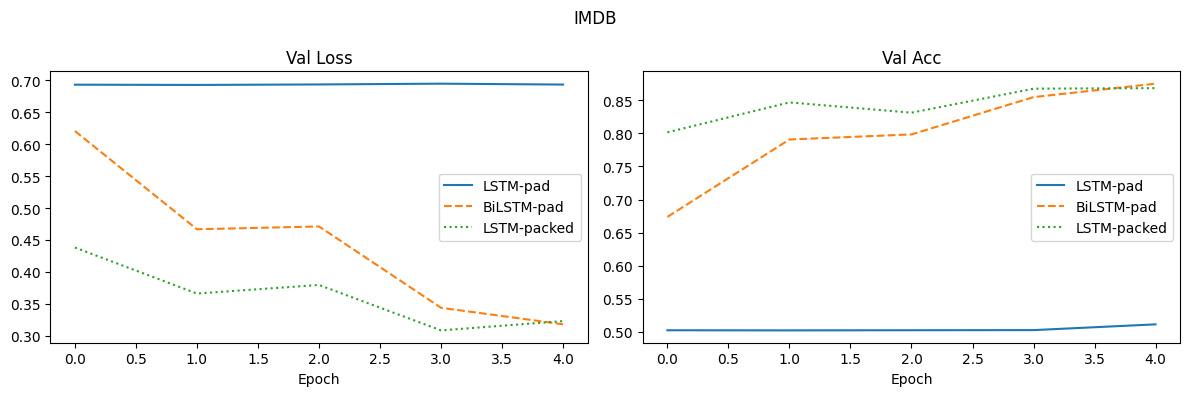


Wariant                     Best Acc    Best F1
-----------------------------------------------
LSTM-pad                      0.5114     0.3918
BiLSTM-pad                    0.8751     0.8749
LSTM-packed                   0.8683     0.8679


In [14]:
plot_results([
    ("LSTM-pad",    h_imdb_pad,  '-'),
    ("BiLSTM-pad",  h_imdb_bi,   '--'),
    ("LSTM-packed", h_imdb_pack, ':'),
], "IMDB")

In [19]:
h_imdb_pad, m1v2   = run_experiment("IMDB: LSTM + padded",   {**BASE_IMDB, 'bidirectional': False, 'packed': False,}, dl_pad,   dl_pad_v,  2)


--- IMDB: LSTM + padded ---
Epoch 1/5 | Train Loss: 0.6935 | Train Acc: 0.5015 | Val Loss: 0.6931 | Val Acc: 0.5016 | Val F1: 0.3441
Epoch 2/5 | Train Loss: 0.6933 | Train Acc: 0.5025 | Val Loss: 0.6931 | Val Acc: 0.5022 | Val F1: 0.3352
Epoch 3/5 | Train Loss: 0.6931 | Train Acc: 0.5018 | Val Loss: 0.6929 | Val Acc: 0.5026 | Val F1: 0.3388
Epoch 4/5 | Train Loss: 0.6922 | Train Acc: 0.5054 | Val Loss: 0.6930 | Val Acc: 0.4989 | Val F1: 0.3422
Epoch 5/5 | Train Loss: 0.6864 | Train Acc: 0.5259 | Val Loss: 0.6607 | Val Acc: 0.6110 | Val F1: 0.5743
Czas: 12.8 min (767s)


In [21]:
# ── Insect ────────────────────────────────────────────────────────────────────
INSECT_DS    = InsectDataset(X, y)
INSECT_FEATS = INSECT_DS.x[0].shape[1]   # n_channels
NUM_INSECTS  = len(INSECT_DS.classes)

train_ins, test_ins   = get_insect_dataloaders(X, y, batch_size=BATCH, variant='padded')
train_ins_p, test_ins_p = get_insect_dataloaders(X, y, batch_size=BATCH, variant='packed')

BASE_INS = dict(input_size=INSECT_FEATS, hidden_size=HIDDEN,
                num_layers=LAYERS, num_classes=NUM_INSECTS, embed=False)

h_ins_pad, m4  = run_experiment("Insect: LSTM + padded",   {**BASE_INS, 'bidirectional': False, 'packed': False}, train_ins,   test_ins,   NUM_INSECTS, EPOCHS*2)
h_ins_bi, m5   = run_experiment("Insect: BiLSTM + padded", {**BASE_INS, 'bidirectional': True,  'packed': False}, train_ins,   test_ins,   NUM_INSECTS, EPOCHS*2)
h_ins_pack, m6 = run_experiment("Insect: LSTM + packed",   {**BASE_INS, 'bidirectional': False, 'packed': True},  train_ins_p, test_ins_p, NUM_INSECTS, EPOCHS*2)


--- Insect: LSTM + padded ---
Epoch 1/10 | Train Loss: 1.2243 | Train Acc: 0.5120 | Val Loss: 0.9993 | Val Acc: 0.6014 | Val F1: 0.5930
Epoch 2/10 | Train Loss: 0.8981 | Train Acc: 0.6418 | Val Loss: 0.9114 | Val Acc: 0.6339 | Val F1: 0.6330
Epoch 3/10 | Train Loss: 0.7953 | Train Acc: 0.6796 | Val Loss: 0.8812 | Val Acc: 0.6455 | Val F1: 0.6391
Epoch 4/10 | Train Loss: 0.7163 | Train Acc: 0.7139 | Val Loss: 0.8870 | Val Acc: 0.6612 | Val F1: 0.6573
Epoch 5/10 | Train Loss: 0.6556 | Train Acc: 0.7406 | Val Loss: 0.8548 | Val Acc: 0.6710 | Val F1: 0.6683
Epoch 6/10 | Train Loss: 0.6006 | Train Acc: 0.7652 | Val Loss: 0.8771 | Val Acc: 0.6771 | Val F1: 0.6742
Epoch 7/10 | Train Loss: 0.5526 | Train Acc: 0.7841 | Val Loss: 0.9195 | Val Acc: 0.6722 | Val F1: 0.6700
Epoch 8/10 | Train Loss: 0.5086 | Train Acc: 0.8038 | Val Loss: 0.9253 | Val Acc: 0.6708 | Val F1: 0.6686
Epoch 9/10 | Train Loss: 0.4696 | Train Acc: 0.8211 | Val Loss: 0.9560 | Val Acc: 0.6697 | Val F1: 0.6685
Epoch 10/10 | T

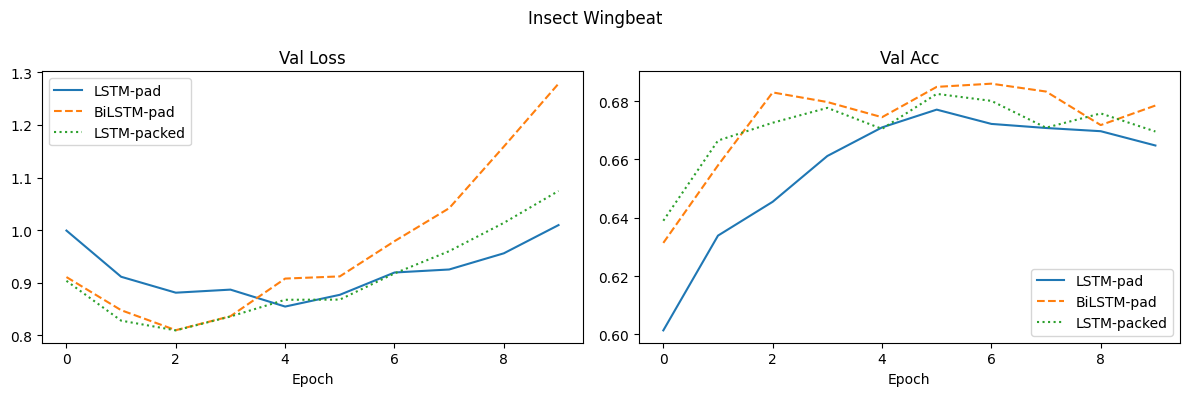


Wariant                     Best Acc    Best F1
-----------------------------------------------
LSTM-pad                      0.6771     0.6742
BiLSTM-pad                    0.6860     0.6862
LSTM-packed                   0.6825     0.6826


In [22]:
plot_results([
    ("LSTM-pad",    h_ins_pad,  '-'),
    ("BiLSTM-pad",  h_ins_bi,   '--'),
    ("LSTM-packed", h_ins_pack, ':'),
], "Insect Wingbeat")

# Zadanie 3

Dla modelu językowego, dokonaj wizualizacji embeddingów 10 przykładowych słów. Dobierz słowa samodzielnie tak, aby pokazać, że embedding częściowo (ale prwadopodobnie nie idealnie) oddają relacje semantyczne. Możesz wykorzystać gotowe metody redukcji wymiarowości np. z scikit-learn aby umieścić embeddingi w przestrzeni dwuwymiarowej.

Ponieważ zbiór pobierany z tf.keras jest już reprezentowany w postaci list liczb całkowitych, bedziesz korzystać ze słownika indeksów również dostępnego w tf.keras:

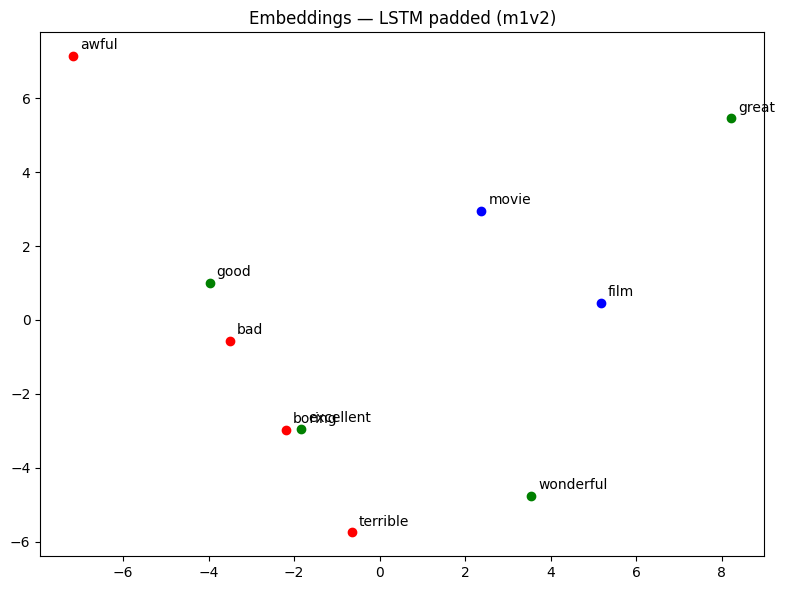

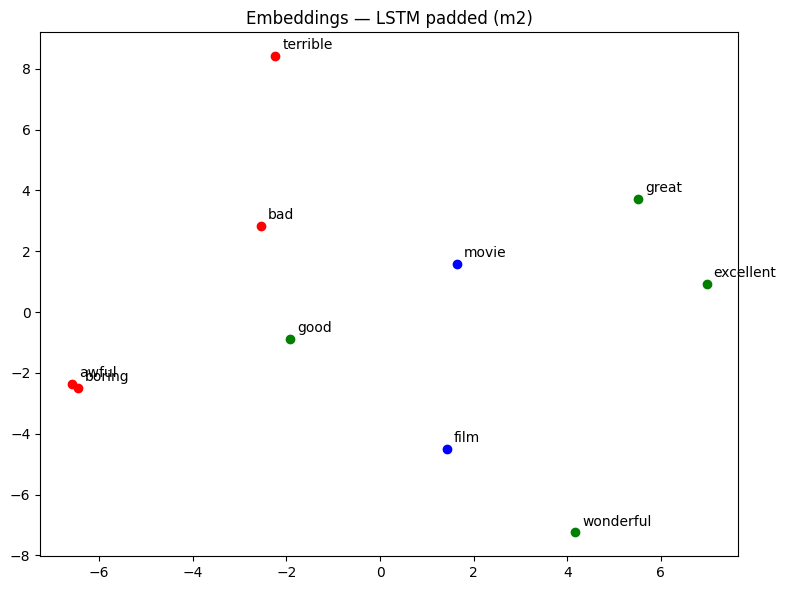

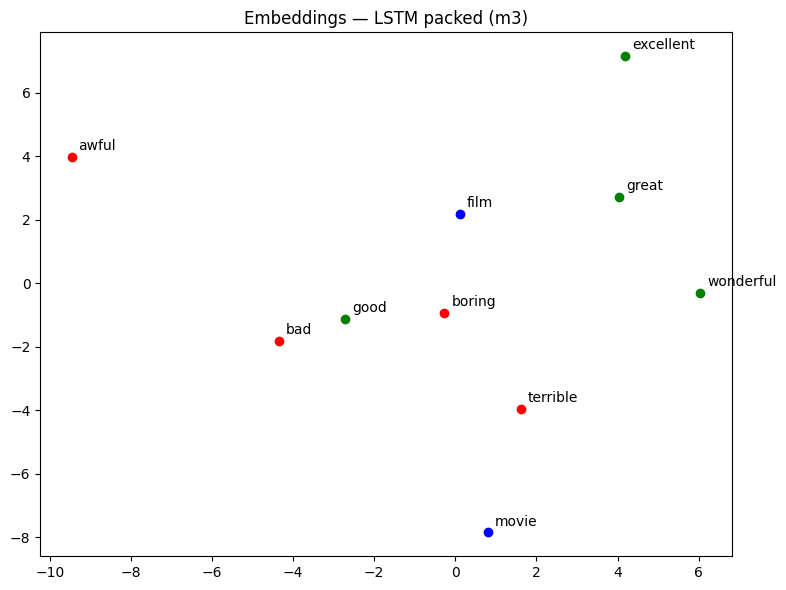

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

words = ["good", "great", "excellent", "wonderful",
         "bad",  "terrible", "awful",   "boring",
         "film", "movie"]

# indeksy w IMDB są przesunięte o +3 (index_from=3)
word_index = imdb.get_word_index(path='imdb_word_index.json')
indices = [word_index[w] + 3 for w in words]

def plot_embeddings(model, title):
    weights = model.embedding.weight.detach().cpu().numpy()
    vecs = np.array([weights[i] for i in indices])

    coords = PCA(n_components=2).fit_transform(vecs)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title(title)
    colors = ['green'] * 4 + ['red'] * 4 + ['blue'] * 2
    for (x, y), word, c in zip(coords, words, colors):
        ax.scatter(x, y, color=c)
        ax.annotate(word, (x, y), textcoords="offset points", xytext=(5, 5))
    plt.tight_layout()
    plt.show()

plot_embeddings(m1v2, "Embeddings — LSTM padded (m1v2)")
plot_embeddings(m2, "Embeddings — LSTM padded (m2)")
plot_embeddings(m3, "Embeddings — LSTM packed (m3)")
